# Numerical Integration

In [30]:
%pip install numpy matplotlib scipy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Motivation

In the optimization and EM lectures, we worked with log-likelihoods and maximized them directly. But many statistical problems require computing *integrals* that have no closed-form solution. These integrals arise in three fundamental settings:

**Marginal likelihoods.** In mixed-effects models, we observe data $\mathbf{y}$ and posit latent random effects $\mathbf{b}$. The marginal likelihood integrates out the random effects:

$$L(\boldsymbol{\theta}) = \int f(\mathbf{y} | \mathbf{b}, \boldsymbol{\theta}) \, f(\mathbf{b} | \boldsymbol{\theta}) \, d\mathbf{b}$$

**Normalizing constants.** In Bayesian inference, the posterior is $p(\boldsymbol{\theta} | \mathbf{y}) = p(\mathbf{y} | \boldsymbol{\theta}) p(\boldsymbol{\theta}) / p(\mathbf{y})$, where $p(\mathbf{y}) = \int p(\mathbf{y} | \boldsymbol{\theta}) p(\boldsymbol{\theta}) \, d\boldsymbol{\theta}$ is often intractable.

**Posterior expectations.** Bayesian point estimates and credible intervals require expectations like $E[\theta | \mathbf{y}] = \int \theta \, p(\theta | \mathbf{y}) \, d\theta$.

In the EM algorithm, we encountered this directly: the E-step of MCEM required Monte Carlo approximation because the conditional expectation $E[\log f(\mathbf{Y}, \mathbf{Z} | \boldsymbol{\theta}) | \mathbf{Y}, \boldsymbol{\theta}^{(t)}]$ involved an intractable integral over the latent variable space. The methods we develop in this lecture provide a systematic toolkit for handling such integrals.

### Running Example: Poisson-Lognormal GLMM

As a concrete running example, consider a Poisson-lognormal generalized linear mixed model. We observe counts $y_i$ for $i = 1, \ldots, n$ subjects, each with a subject-specific random intercept $b_i$:

$$y_i | b_i \sim \text{Poisson}(\exp(\beta_0 + b_i)), \qquad b_i \sim N(0, \sigma^2)$$

The marginal likelihood for a single observation is:

$$L_i(\beta_0, \sigma^2) = \int_{-\infty}^{\infty} \frac{\exp(y_i(\beta_0 + b) - e^{\beta_0 + b})}{y_i!} \cdot \frac{1}{\sqrt{2\pi}\sigma} \exp\left(-\frac{b^2}{2\sigma^2}\right) db$$

The product of the Poisson mass function and the normal density has no closed-form integral due to the $\exp(-e^{\beta_0 + b})$ term in the Poisson likelihood. Unlike the normal-normal or Poisson-gamma conjugate pairs, the Poisson-lognormal pair does not simplify, so we must use numerical methods.

Let us set up this example with simulated data:

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.integrate import quad
from scipy.optimize import minimize_scalar, minimize

np.random.seed(42)

# Simulate Poisson-lognormal data
n = 50
beta0_true = 1.0
sigma_true = 0.8

b_true = np.random.normal(0, sigma_true, n)
y = np.random.poisson(np.exp(beta0_true + b_true))

print(f"Simulated data: n={n}, mean(y)={np.mean(y):.2f}, var(y)={np.var(y):.2f}")
print(f"First 10 observations: {y[:10]}")
print(f"True parameters: beta0={beta0_true}, sigma={sigma_true}")

Simulated data: n=50, mean(y)=2.96, var(y)=6.08
First 10 observations: [2 3 5 7 3 5 3 7 0 7]
True parameters: beta0=1.0, sigma=0.8


Since there is no closed-form solution, we must resort to numerical methods. Let us compute the marginal likelihood for a single observation using adaptive quadrature (`scipy.integrate.quad`) as a reference value:

In [32]:
def poisson_lognormal_integrand(b, yi, beta0, sigma):
    """Integrand for the Poisson-lognormal marginal likelihood."""
    log_poisson = yi * (beta0 + b) - np.exp(np.clip(beta0 + b, None, 500)) - np.sum(
        np.log(np.arange(1, yi + 1))
    )
    log_normal = -0.5 * np.log(2 * np.pi) - np.log(sigma) - b**2 / (2 * sigma**2)
    return np.exp(log_poisson + log_normal)


# Compute marginal likelihood for first observation using numerical quadrature
Li_quad, error = quad(poisson_lognormal_integrand, -np.inf, np.inf,
                      args=(y[0], beta0_true, sigma_true))
print(f"Observation y[0]={y[0]}")
print(f"Marginal likelihood L_0 = {Li_quad:.6e} (quadrature error: {error:.2e})")

Observation y[0]=2
Marginal likelihood L_0 = 1.655009e-01 (quadrature error: 1.08e-08)


This single integral required an adaptive algorithm with many function evaluations. For the full marginal likelihood $L(\beta_0, \sigma^2) = \prod_{i=1}^n L_i$, we would need to compute $n$ such integrals at each step of an optimization routine.

### Benchmark Integral

Throughout this lecture, we will compare different numerical integration methods on a simple benchmark integral with a known exact value:

$$I = \int_0^1 e^{-x^2} \, dx$$

This integral does not have a closed-form antiderivative (its solution involves the error function). We can compute a highly accurate reference value using scipy:

In [33]:
exact_value, _ = quad(lambda x: np.exp(-x**2), 0, 1)
print(f"Benchmark integral: I = {exact_value:.15f}")

Benchmark integral: I = 0.746824132812427


### Question

Why does the Poisson-lognormal marginal likelihood not have a closed-form solution, while the Poisson-gamma model (negative binomial) does? What structural property of the integrand makes the difference?

### Answer

In the Poisson-gamma model, the Poisson likelihood $e^{-\lambda} \lambda^y / y!$ combined with the gamma prior $\lambda^{a-1} e^{-b\lambda}$ gives an integrand proportional to $\lambda^{y+a-1} e^{-(b+1)\lambda}$, which is a gamma kernel. The integral evaluates to $\Gamma(y+a) / (b+1)^{y+a}$ in closed form because the Poisson and gamma distributions are conjugate.

In the Poisson-lognormal model, the Poisson likelihood has $\exp(-e^{\beta_0+b})$ while the lognormal (really normal on $b$) prior has $\exp(-b^2/(2\sigma^2))$. These two exponential terms cannot be combined into a recognizable kernel of any standard distribution. The double exponential structure $\exp(-e^{\text{something}})$ prevents simplification. There is no conjugacy, so the integral must be evaluated numerically.

## Deterministic Quadrature

The most direct approach to numerical integration is to approximate the integral by a weighted sum of function evaluations:

$$\int_a^b f(x) \, dx \approx \sum_{i=0}^{n} w_i f(x_i)$$

Different choices of the nodes $x_i$ and weights $w_i$ give different quadrature rules with different accuracy properties.

### Trapezoidal Rule

The simplest approach is to approximate $f(x)$ by piecewise linear functions. On a single interval $[a, b]$:

$$\int_a^b f(x) \, dx \approx \frac{b - a}{2} [f(a) + f(b)]$$

This is exact for linear functions. For the composite trapezoidal rule with $n$ equally-spaced subintervals of width $h = (b - a)/n$, the approximation is:

$$\int_a^b f(x) \, dx \approx \frac{h}{2} \left[ f(x_0) + 2\sum_{i=1}^{n-1} f(x_i) + f(x_n) \right]$$

where $x_i = a + ih$. The error is $O(h^2)$, meaning that doubling the number of points reduces the error by a factor of approximately 4.

In [34]:
def trapezoidal(f, a, b, n):
    """Composite trapezoidal rule with n subintervals."""
    x = np.linspace(a, b, n + 1)
    fx = f(x)
    h = (b - a) / n
    return h * (0.5 * fx[0] + np.sum(fx[1:-1]) + 0.5 * fx[-1])


# Apply to benchmark integral
f_bench = lambda x: np.exp(-x**2)
for n in [4, 8, 16, 32, 64]:
    approx = trapezoidal(f_bench, 0, 1, n)
    error = abs(approx - exact_value)
    print(f"n={n:3d}: I ≈ {approx:.10f}, error = {error:.2e}")

n=  4: I ≈ 0.7429840978, error = 3.84e-03
n=  8: I ≈ 0.7458656148, error = 9.59e-04
n= 16: I ≈ 0.7465845968, error = 2.40e-04
n= 32: I ≈ 0.7467642547, error = 5.99e-05
n= 64: I ≈ 0.7468091636, error = 1.50e-05


### Simpson's Rule

Simpson's rule approximates $f(x)$ by piecewise quadratic functions instead of linear ones. On a single interval $[a, b]$ with midpoint $m = (a + b)/2$:

$$\int_a^b f(x) \, dx \approx \frac{b - a}{6} [f(a) + 4f(m) + f(b)]$$

This is exact for polynomials up to degree 3 (one degree higher than expected from a quadratic fit, due to symmetry). For the composite form with $n$ subintervals ($n$ must be even):

$$\int_a^b f(x) \, dx \approx \frac{h}{3} \left[ f(x_0) + 4f(x_1) + 2f(x_2) + 4f(x_3) + \cdots + 4f(x_{n-1}) + f(x_n) \right]$$

The error is $O(h^4)$, so doubling the number of points reduces the error by a factor of approximately 16.

In [35]:
def simpsons(f, a, b, n):
    """Composite Simpson's rule with n subintervals (n must be even)."""
    if n % 2 != 0:
        raise ValueError("n must be even for Simpson's rule")
    x = np.linspace(a, b, n + 1)
    fx = f(x)
    h = (b - a) / n
    return (h / 3) * (
        fx[0] + fx[-1]
        + 4 * np.sum(fx[1:-1:2])
        + 2 * np.sum(fx[2:-2:2])
    )


# Apply to benchmark integral
for n in [4, 8, 16, 32, 64]:
    approx = simpsons(f_bench, 0, 1, n)
    error = abs(approx - exact_value)
    print(f"n={n:3d}: I ≈ {approx:.12f}, error = {error:.2e}")

n=  4: I ≈ 0.746855379791, error = 3.12e-05
n=  8: I ≈ 0.746826120527, error = 1.99e-06
n= 16: I ≈ 0.746824257436, error = 1.25e-07
n= 32: I ≈ 0.746824140607, error = 7.79e-09
n= 64: I ≈ 0.746824133300, error = 4.87e-10


### Convergence Rate Comparison

Let us verify the theoretical convergence rates by plotting the error on a log-log scale. The trapezoidal rule should show slope $-2$ and Simpson's rule should show slope $-4$:

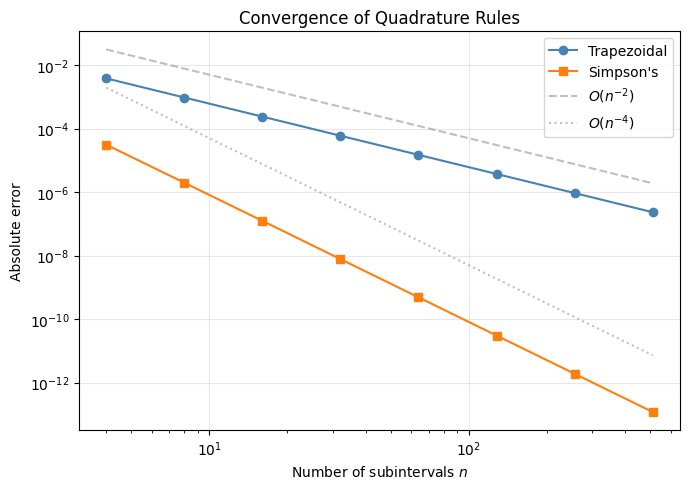

In [36]:
ns = np.array([4, 8, 16, 32, 64, 128, 256, 512])
errors_trap = np.array([abs(trapezoidal(f_bench, 0, 1, n) - exact_value) for n in ns])
errors_simp = np.array(
    [abs(simpsons(f_bench, 0, 1, n) - exact_value) for n in ns]
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(ns, errors_trap, "o-", label="Trapezoidal", color="steelblue")
ax.loglog(ns, errors_simp, "s-", label="Simpson's", color="tab:orange")

# Reference slopes
ax.loglog(ns, 0.5 * ns.astype(float) ** (-2), "--", color="gray", alpha=0.5,
          label="$O(n^{-2})$")
ax.loglog(ns, 0.5 * ns.astype(float) ** (-4), ":", color="gray", alpha=0.5,
          label="$O(n^{-4})$")

ax.set_xlabel("Number of subintervals $n$")
ax.set_ylabel("Absolute error")
ax.set_title("Convergence of Quadrature Rules")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

### Question

Suppose you are using the composite trapezoidal rule and the error with $n = 100$ subintervals is $10^{-4}$. Approximately what error do you expect with $n = 200$? What about with $n = 400$? How many subintervals would be needed to achieve an error of $10^{-10}$?

### Answer

The trapezoidal rule has $O(h^2) = O(n^{-2})$ error. Doubling $n$ from 100 to 200 multiplies $n^{-2}$ by $1/4$, so the error drops to approximately $2.5 \times 10^{-5}$. Doubling again to $n = 400$ gives approximately $6.25 \times 10^{-6}$.

To achieve $10^{-10}$ starting from error $10^{-4}$ at $n = 100$: we need a factor of $10^{-6}$ improvement, which means $n^{-2}$ must decrease by $10^{6}$. So $n$ must increase by $10^3$, giving $n = 100{,}000$. By contrast, Simpson's rule with $O(n^{-4})$ error would need only $n \approx 100 \times 10^{6/4} \approx 3{,}162$ subintervals for the same accuracy.

### Gaussian Quadrature

The quadrature rules above use equally-spaced nodes. Gaussian quadrature achieves much higher accuracy by choosing *both* the nodes and weights optimally. The key result is that $n$-point Gaussian quadrature is exact for polynomials of degree up to $2n - 1$.

**Gauss-Legendre quadrature** approximates integrals on $[-1, 1]$:

$$\int_{-1}^{1} f(x) \, dx \approx \sum_{i=1}^{n} w_i f(x_i)$$

where the nodes $x_i$ are roots of the Legendre polynomial $P_n(x)$. For integrals on $[a, b]$, we transform: $x = \frac{b-a}{2}t + \frac{a+b}{2}$.

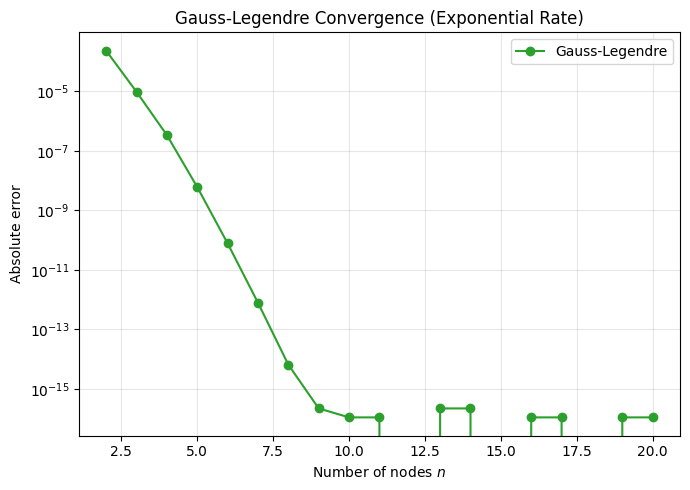

In [54]:
from numpy.polynomial.legendre import leggauss

# Gauss-Legendre quadrature for the benchmark integral on [0, 1]
ns_gl = np.arange(2, 21)
errors_gl = []
for n in ns_gl:
    nodes, weights = leggauss(n)
    # Transform from [-1, 1] to [0, 1]
    x = 0.5 * nodes + 0.5
    w = 0.5 * weights
    approx = np.sum(w * f_bench(x))
    errors_gl.append(abs(approx - exact_value))

errors_gl = np.array(errors_gl)

fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogy(ns_gl, errors_gl, "o-", color="tab:green", label="Gauss-Legendre")
ax.set_xlabel("Number of nodes $n$")
ax.set_ylabel("Absolute error")
ax.set_title("Gauss-Legendre Convergence (Exponential Rate)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

The error decreases *exponentially* with $n$ for smooth functions, far faster than the polynomial rates of the trapezoidal and Simpson's rules. With only about 10 nodes, Gauss-Legendre achieves machine precision for this smooth integrand.

### Gauss-Hermite Quadrature

For integrals of the form $\int_{-\infty}^{\infty} g(x) e^{-x^2} dx$, **Gauss-Hermite** quadrature is designed to handle the Gaussian weight function directly:

$$\int_{-\infty}^{\infty} g(x) e^{-x^2} \, dx \approx \sum_{i=1}^{n} w_i g(x_i)$$

This is particularly relevant for statistics because many integrals involve normal distributions. For the integral $\int_{-\infty}^{\infty} h(x) \frac{1}{\sqrt{2\pi}\sigma} e^{-(x-\mu)^2/(2\sigma^2)} dx$, we substitute $t = (x - \mu)/(\sqrt{2}\sigma)$ to get:

$$\int_{-\infty}^{\infty} h(\sqrt{2}\sigma t + \mu) \frac{e^{-t^2}}{\sqrt{\pi}} \, dt \approx \frac{1}{\sqrt{\pi}} \sum_{i=1}^{n} w_i \, h(\sqrt{2}\sigma t_i + \mu)$$

Let us apply Gauss-Hermite quadrature to our Poisson-lognormal running example:

In [55]:
from numpy.polynomial.hermite import hermgauss


def marginal_lik_GH(yi, beta0, sigma, n_nodes):
    """Gauss-Hermite approximation to the Poisson-lognormal marginal likelihood."""
    nodes, weights = hermgauss(n_nodes)
    # Transform: b = sqrt(2) * sigma * t, so integrate h(b) * N(b|0,sigma^2) db
    b_vals = np.sqrt(2) * sigma * nodes
    log_poisson = yi * (beta0 + b_vals) - np.exp(beta0 + b_vals)
    # The log(yi!) term cancels in likelihood ratios, but we include it for correctness
    log_factorial = np.sum(np.log(np.arange(1, yi + 1))) if yi > 0 else 0.0
    poisson_vals = np.exp(log_poisson - log_factorial)
    return np.sum(weights * poisson_vals) / np.sqrt(np.pi)


# Compare Gauss-Hermite with different numbers of nodes to exact quadrature
for n_nodes in [5, 10, 15, 20, 30]:
    Li_gh = marginal_lik_GH(y[0], beta0_true, sigma_true, n_nodes)
    rel_error = abs(Li_gh - Li_quad) / Li_quad
    print(f"n_nodes={n_nodes:2d}: L_0 = {Li_gh:.6e}, relative error = {rel_error:.2e}")

n_nodes= 5: L_0 = 1.700712e-01, relative error = 2.76e-02
n_nodes=10: L_0 = 1.654163e-01, relative error = 5.11e-04
n_nodes=15: L_0 = 1.654870e-01, relative error = 8.42e-05
n_nodes=20: L_0 = 1.655015e-01, relative error = 3.78e-06
n_nodes=30: L_0 = 1.655009e-01, relative error = 5.97e-08


### Question

In what situations would you prefer Gaussian quadrature over the trapezoidal or Simpson's rule? When might Gaussian quadrature perform poorly?

### Answer

Gaussian quadrature is preferable when: (1) the integrand is smooth and the integration domain is known, because it achieves exponential convergence and can reach high accuracy with very few nodes; (2) a natural weight function (like the Gaussian kernel for Gauss-Hermite) matches the structure of the integrand, as in GLMM marginal likelihoods.

Gaussian quadrature may perform poorly when: (1) the integrand has discontinuities or sharp peaks that do not align with the node placement, because the polynomial interpolation assumption breaks down; (2) the number of dimensions is large, since the number of nodes grows as $n^d$ (curse of dimensionality); (3) the integration domain or weight function does not match any standard family.

### Curse of Dimensionality

All the quadrature rules above extend to multiple dimensions via product rules. For a $d$-dimensional integral with $n$ nodes per dimension, the total number of function evaluations is $n^d$. This exponential growth makes deterministic quadrature infeasible for high-dimensional problems.

For example, consider a spatial GLMM with 70 correlated random effects $\mathbf{b} \sim N(\mathbf{0}, \boldsymbol{\Sigma})$ where $\boldsymbol{\Sigma}$ encodes spatial correlation. Because the random effects are correlated, the marginal likelihood involves a single 70-dimensional integral that cannot be factorized into lower-dimensional components. Even with just $n = 5$ nodes per dimension, product-rule quadrature would require $5^{70} \approx 8.5 \times 10^{48}$ function evaluations. At $10^9$ evaluations per second, this would take approximately $2.7 \times 10^{32}$ years, far exceeding the age of the universe ($1.4 \times 10^{10}$ years). (Note: when random effects are *independent*, the integral factorizes into a product of 1D integrals, each of which can be handled efficiently with 1D quadrature.)

### Question

A spatial GLMM has 70 correlated random effects. A collaborator suggests using 5-point Gauss-Hermite quadrature for the marginal likelihood. How many quadrature points would this require? Is this feasible? Would the answer change if the random effects were independent?

### Answer

Product-rule Gauss-Hermite quadrature with 5 nodes per dimension and 70 dimensions requires $5^{70} \approx 8.5 \times 10^{48}$ function evaluations. At $10^9$ evaluations per second, this would take approximately $8.5 \times 10^{39}$ seconds, or about $2.7 \times 10^{32}$ years. The age of the universe is about $1.4 \times 10^{10}$ years, so this is utterly infeasible. This is why we need Monte Carlo methods for high-dimensional integration: their convergence rate is $O(n^{-1/2})$ regardless of dimension.

If the random effects were independent, the 70-dimensional integral would factorize into a product of 70 one-dimensional integrals, each requiring only 5 quadrature nodes ($70 \times 5 = 350$ total evaluations). This is trivially fast. The curse of dimensionality applies to non-separable integrals over correlated random effects.

## Monte Carlo Integration

The curse of dimensionality motivates a fundamentally different approach. Instead of choosing nodes and weights deterministically, Monte Carlo integration uses random sampling. The key insight is that any integral can be rewritten as an expectation:

$$I = \int_a^b f(x) \, dx = (b - a) \int_a^b f(x) \frac{1}{b-a} \, dx = (b - a) \, E_{X \sim \text{Uniform}(a,b)}[f(X)]$$

By the law of large numbers, the sample mean converges to the true expectation:

$$\hat{I}_n = \frac{b-a}{n} \sum_{i=1}^n f(X_i) \xrightarrow{a.s.} I \quad \text{as } n \to \infty$$

where $X_1, \ldots, X_n \stackrel{iid}{\sim} \text{Uniform}(a, b)$.

The central limit theorem gives us a standard error and confidence interval. If $\text{Var}[f(X)] = \sigma_f^2$, then:

$$\sqrt{n}(\hat{I}_n - I) \xrightarrow{d} N(0, (b-a)^2 \sigma_f^2)$$

The standard error of the MC estimate is $\text{SE} = (b-a) \sigma_f / \sqrt{n}$, which decreases as $O(n^{-1/2})$ regardless of the dimension of the integral. This is the critical advantage: the rate does not depend on $d$.

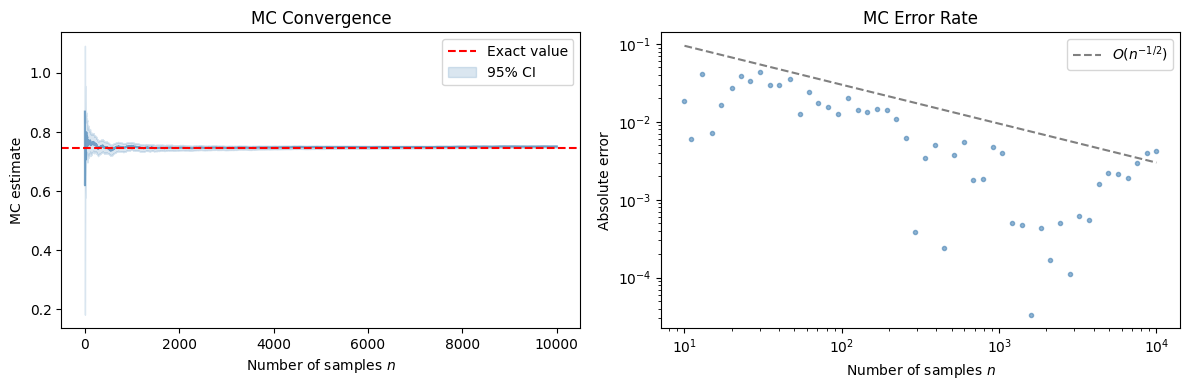

In [39]:
# Monte Carlo estimate of the benchmark integral
np.random.seed(42)
n_mc = 10000
x_mc = np.random.uniform(0, 1, n_mc)
f_mc = np.exp(-x_mc**2)

# Cumulative Monte Carlo estimate
mc_estimates = np.cumsum(f_mc) / np.arange(1, n_mc + 1)
mc_se = np.array(
    [np.std(f_mc[:k], ddof=1) / np.sqrt(k) if k > 1 else np.nan
     for k in range(1, n_mc + 1)]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Convergence plot
axes[0].plot(range(1, n_mc + 1), mc_estimates, color="steelblue", alpha=0.7)
axes[0].axhline(exact_value, color="red", linestyle="--", label="Exact value")
axes[0].fill_between(
    range(1, n_mc + 1),
    mc_estimates - 1.96 * mc_se,
    mc_estimates + 1.96 * mc_se,
    alpha=0.2, color="steelblue", label="95% CI"
)
axes[0].set_xlabel("Number of samples $n$")
axes[0].set_ylabel("MC estimate")
axes[0].set_title("MC Convergence")
axes[0].legend()

# Error vs n on log-log scale
ns_mc = np.logspace(1, 4, 50).astype(int)
mc_errors = np.array(
    [abs(np.mean(f_mc[:n]) - exact_value) for n in ns_mc]
)
axes[1].loglog(ns_mc, mc_errors, "o", markersize=3, color="steelblue", alpha=0.6)
axes[1].loglog(ns_mc, ns_mc.astype(float)**(-0.5) * 0.3, "--", color="gray",
               label="$O(n^{-1/2})$")
axes[1].set_xlabel("Number of samples $n$")
axes[1].set_ylabel("Absolute error")
axes[1].set_title("MC Error Rate")
axes[1].legend()

plt.tight_layout()

The $O(n^{-1/2})$ rate is much slower than the polynomial or exponential rates of quadrature for smooth 1D integrals. But this rate is *dimension-free*: the same $n^{-1/2}$ rate applies whether we are integrating over 1 dimension or 1000.

### Dimension-Free Convergence

To demonstrate that MC convergence is truly dimension-free, let us estimate the integral $\int_{[0,1]^d} \exp(-\|\mathbf{x}\|^2) \, d\mathbf{x}$ for various dimensions $d$. In each case, we draw uniform samples from the unit hypercube and compute the sample mean:

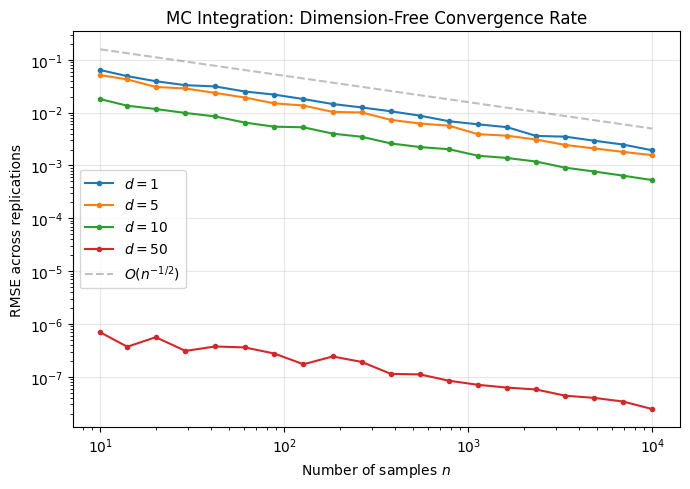

In [40]:
np.random.seed(42)
dims = [1, 5, 10, 50]
n_samples = 10000
n_reps = 200

fig, ax = plt.subplots(figsize=(7, 5))

for d in dims:
    # Estimate SE across replications for increasing sample sizes
    ns_check = np.logspace(1, 4, 20).astype(int)
    rmse_vals = []
    for n_s in ns_check:
        estimates = []
        for _ in range(n_reps):
            x = np.random.uniform(0, 1, (n_s, d))
            estimates.append(np.mean(np.exp(-np.sum(x**2, axis=1))))
        rmse_vals.append(np.std(estimates))
    ax.loglog(ns_check, rmse_vals, "o-", markersize=3, label=f"$d = {d}$")

# Reference slope
ax.loglog(ns_check, 0.5 * ns_check.astype(float)**(-0.5), "--", color="gray",
          alpha=0.5, label="$O(n^{-1/2})$")
ax.set_xlabel("Number of samples $n$")
ax.set_ylabel("RMSE across replications")
ax.set_title("MC Integration: Dimension-Free Convergence Rate")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

The slopes are parallel across all dimensions, confirming the $O(n^{-1/2})$ rate regardless of $d$. The constant factor (vertical offset) depends on $\text{Var}[f(\mathbf{X})]$, which is problem-dependent. The key point is that the *rate* of convergence is unchanged by dimension. This is why MC methods dominate for high-dimensional integrals.

### MC for the Poisson-Lognormal Running Example

We can estimate the Poisson-lognormal marginal likelihood using simple MC: draw $b_1, \ldots, b_M \sim N(0, \sigma^2)$ and average the Poisson likelihoods:

$$\hat{L}_i = \frac{1}{M} \sum_{m=1}^M f(y_i | b_m, \beta_0) = \frac{1}{M} \sum_{m=1}^M \frac{e^{y_i(\beta_0 + b_m) - e^{\beta_0 + b_m}}}{y_i!}$$

In [41]:
def marginal_lik_MC(yi, beta0, sigma, M, rng=None):
    """Monte Carlo estimate of the Poisson-lognormal marginal likelihood."""
    if rng is None:
        rng = np.random.default_rng()
    b_samples = rng.normal(0, sigma, M)
    log_poisson = yi * (beta0 + b_samples) - np.exp(beta0 + b_samples)
    log_factorial = np.sum(np.log(np.arange(1, yi + 1))) if yi > 0 else 0.0
    poisson_vals = np.exp(log_poisson - log_factorial)
    return np.mean(poisson_vals), np.std(poisson_vals, ddof=1) / np.sqrt(M)


# Compare MC with different sample sizes to exact quadrature
rng = np.random.default_rng(42)
print(f"Observation y[0]={y[0]}, exact quadrature: {Li_quad:.6e}\n")
for M in [100, 1000, 10000, 100000]:
    mc_est, mc_se_est = marginal_lik_MC(y[0], beta0_true, sigma_true, M, rng)
    rel_err = abs(mc_est - Li_quad) / Li_quad
    print(f"M={M:>6d}: L_0 = {mc_est:.6e} ± {mc_se_est:.2e}, rel error = {rel_err:.4e}")

Observation y[0]=2, exact quadrature: 1.655009e-01

M=   100: L_0 = 1.834585e-01 ± 7.76e-03, rel error = 1.0850e-01
M=  1000: L_0 = 1.671663e-01 ± 2.86e-03, rel error = 1.0063e-02
M= 10000: L_0 = 1.656219e-01 ± 9.21e-04, rel error = 7.3142e-04
M=100000: L_0 = 1.658288e-01 ± 2.91e-04, rel error = 1.9814e-03


Even with $M = 100{,}000$ samples, the MC estimate has noticeable variability. For optimizing the marginal likelihood (which requires evaluating it repeatedly at different parameter values), this noise makes gradient-based optimization difficult. This motivates either Gauss-Hermite quadrature (exact, deterministic) or Laplace approximation (fast, deterministic) for this type of problem.

### Monte Carlo for Posterior Expectations

A natural application is computing posterior expectations. Consider a Beta-Binomial conjugate model: we observe $y = 7$ successes in $n = 10$ trials with a $\text{Beta}(2, 2)$ prior. The posterior is $\text{Beta}(9, 5)$, and the posterior mean is $E[\theta | y] = 9/14 \approx 0.6429$.

In [42]:
# Exact posterior (conjugate)
a_post, b_post = 9, 5
exact_mean = a_post / (a_post + b_post)
print(f"Exact posterior mean: {exact_mean:.6f}")

# Monte Carlo estimate
np.random.seed(42)
n_mc_post = 50000
theta_samples = np.random.beta(a_post, b_post, n_mc_post)
mc_mean = np.mean(theta_samples)
mc_se_mean = np.std(theta_samples, ddof=1) / np.sqrt(n_mc_post)
print(f"MC posterior mean: {mc_mean:.6f} ± {mc_se_mean:.6f}")
print(f"MC 95% credible interval: ({np.percentile(theta_samples, 2.5):.4f}, "
      f"{np.percentile(theta_samples, 97.5):.4f})")

Exact posterior mean: 0.642857
MC posterior mean: 0.643209 ± 0.000551
MC 95% credible interval: (0.3856, 0.8609)


The advantage of Monte Carlo is that once we have posterior samples, we can compute *any* functional of the posterior (mean, variance, quantiles, probabilities) from the same samples.

### Question

At what dimension $d$ does Monte Carlo integration become more efficient than product-rule quadrature with $n$ points per dimension?

Consider the error rates: a composite quadrature rule with $O(n^{-r})$ error in 1D and $N = n^d$ total evaluations achieves $O(N^{-r/d})$ error in $d$ dimensions (since $n = N^{1/d}$). Monte Carlo achieves $O(N^{-1/2})$ regardless of $d$. At what $d$ does MC win?

### Answer

Setting $N^{-r/d} = N^{-1/2}$, MC becomes more efficient when $r/d < 1/2$, i.e., when $d > 2r$. For the trapezoidal rule ($r = 2$), MC wins when $d > 4$. For Simpson's rule ($r = 4$), MC wins when $d > 8$. For Gaussian quadrature with exponential convergence, deterministic methods can remain competitive in somewhat higher dimensions, but by $d \approx 10$-$20$, MC is typically the practical choice.

This explains the "crossover" in practice: for 1D and 2D integrals, quadrature rules are vastly superior. For moderate dimensions (3-8), adaptive quadrature may still work. For high-dimensional integrals (common in mixed models and Bayesian inference), Monte Carlo is essential.

### Variance Reduction: Antithetic Variables

Simple MC can be improved by reducing the variance of the estimator. The antithetic variables method exploits the symmetry of the uniform distribution: if $U \sim \text{Uniform}(0,1)$, then $1 - U \sim \text{Uniform}(0,1)$, and $f(U)$ and $f(1-U)$ are negatively correlated when $f$ is monotone. Using the average $(f(U) + f(1-U))/2$ reduces variance:

In [43]:
np.random.seed(42)
n_anti = 5000

u = np.random.uniform(0, 1, n_anti)
f_u = np.exp(-u**2)
f_anti = np.exp(-(1 - u)**2)

# Standard MC (using 2*n_anti samples for fair comparison)
u_standard = np.random.uniform(0, 1, 2 * n_anti)
f_standard = np.exp(-u_standard**2)
mc_standard = np.mean(f_standard)
se_standard = np.std(f_standard, ddof=1) / np.sqrt(2 * n_anti)

# Antithetic MC (n_anti pairs = 2*n_anti function evaluations)
mc_antithetic = np.mean(0.5 * (f_u + f_anti))
# Variance of pairwise averages
pair_avg = 0.5 * (f_u + f_anti)
se_antithetic = np.std(pair_avg, ddof=1) / np.sqrt(n_anti)

print(f"Standard MC:   {mc_standard:.6f} ± {se_standard:.6f}")
print(f"Antithetic MC: {mc_antithetic:.6f} ± {se_antithetic:.6f}")
print(f"Variance reduction factor: {se_standard**2 / se_antithetic**2:.2f}x")

Standard MC:   0.749555 ± 0.002008
Antithetic MC: 0.746615 ± 0.000402
Variance reduction factor: 24.92x


Antithetic variables are simple to implement and provide modest but consistent variance reduction for monotone integrands. For larger gains, we turn to importance sampling.

## Importance Sampling

### Motivation: When Naive MC Fails

Monte Carlo integration can be extremely inefficient when the integrand is concentrated in a small region. Consider estimating the probability $P(Z > 4)$ where $Z \sim N(0, 1)$. The true value is approximately $3.17 \times 10^{-5}$:

In [44]:
true_prob = 1 - stats.norm.cdf(4)
print(f"True P(Z > 4) = {true_prob:.6e}")

# Naive Monte Carlo
np.random.seed(42)
n_naive = 100000
z_samples = np.random.normal(0, 1, n_naive)
naive_est = np.mean(z_samples > 4)
naive_se = np.std(z_samples > 4, ddof=1) / np.sqrt(n_naive)
print(f"Naive MC: {naive_est:.6e} ± {naive_se:.6e}")
print(f"Number of samples exceeding 4: {np.sum(z_samples > 4)}")

True P(Z > 4) = 3.167124e-05
Naive MC: 1.000000e-05 ± 1.000000e-05
Number of samples exceeding 4: 1


With 100,000 samples, very few exceed 4, so the estimate is based on a handful of indicator function evaluations. The relative error is enormous. We need a smarter sampling strategy.

### The Importance Sampling Estimator

The core idea is to sample from a different distribution $q(x)$ (the **proposal** or **importance distribution**) that places more mass in the important region, then correct for the change of measure using **importance weights**:

$$I = \int f(x) p(x) \, dx = \int f(x) \frac{p(x)}{q(x)} q(x) \, dx = E_q\left[f(X) \frac{p(X)}{q(X)}\right]$$

The IS estimator is:

$$\hat{I}_{\text{IS}} = \frac{1}{n} \sum_{i=1}^n f(X_i) \frac{p(X_i)}{q(X_i)}, \qquad X_i \sim q$$

This is unbiased as long as $q(x) > 0$ wherever $f(x)p(x) \neq 0$ (the **support condition**).

For the tail probability example, we want $I = \int_{4}^{\infty} \phi(x) \, dx = E_q[w(X) \cdot \mathbb{1}(X > 4)]$ where $w(X) = \phi(X)/q(X)$. A good proposal is a shifted exponential distribution $q(x) = \lambda e^{-\lambda(x-4)}$ for $x \geq 4$:

In [45]:
# Importance sampling for P(Z > 4) using shifted exponential proposal
np.random.seed(42)
n_is = 100000
lam = 1.0  # rate parameter for exponential proposal

# Sample from Exp(1) shifted to start at 4
x_is = np.random.exponential(1.0 / lam, n_is) + 4.0

# Importance weights: phi(x) / q(x) where q(x) = lam * exp(-lam*(x-4))
log_weights = stats.norm.logpdf(x_is) - np.log(lam) + lam * (x_is - 4)
weights = np.exp(log_weights)

is_est = np.mean(weights)
is_se = np.std(weights, ddof=1) / np.sqrt(n_is)

print(f"True P(Z > 4):      {true_prob:.6e}")
print(f"Naive MC (n=100k):   {naive_est:.6e} ± {naive_se:.6e}")
print(f"IS estimate (n=100k): {is_est:.6e} ± {is_se:.6e}")
print(f"Relative error - Naive: {abs(naive_est - true_prob) / true_prob:.2%}")
print(f"Relative error - IS:    {abs(is_est - true_prob) / true_prob:.2%}")

True P(Z > 4):      3.167124e-05
Naive MC (n=100k):   1.000000e-05 ± 1.000000e-05
IS estimate (n=100k): 3.170256e-05 ± 1.209278e-07
Relative error - Naive: 68.43%
Relative error - IS:    0.10%


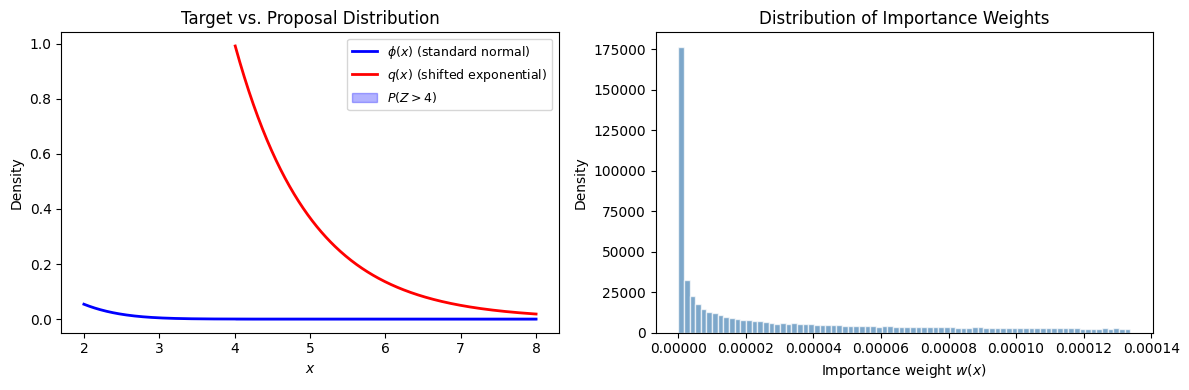

In [46]:
# Visualization
x_grid = np.linspace(2, 8, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: target vs proposal
axes[0].plot(x_grid, stats.norm.pdf(x_grid), "b-", linewidth=2,
             label="$\\phi(x)$ (standard normal)")
x_prop = x_grid[x_grid >= 4]
axes[0].plot(x_prop, lam * np.exp(-lam * (x_prop - 4)), "r-", linewidth=2,
             label="$q(x)$ (shifted exponential)")
axes[0].fill_between(x_grid[x_grid >= 4], stats.norm.pdf(x_grid[x_grid >= 4]),
                     alpha=0.3, color="blue", label="$P(Z > 4)$")
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("Density")
axes[0].set_title("Target vs. Proposal Distribution")
axes[0].legend(fontsize=9)

# Right: weight distribution
axes[1].hist(weights, bins=80, density=True, alpha=0.7, color="steelblue",
             edgecolor="white")
axes[1].set_xlabel("Importance weight $w(x)$")
axes[1].set_ylabel("Density")
axes[1].set_title("Distribution of Importance Weights")

plt.tight_layout()

### Self-Normalized Importance Sampling

In Bayesian inference, we often know the posterior only up to a normalizing constant: $p(\theta | y) \propto p(y | \theta) p(\theta)$. We cannot compute the standard IS weights $p(\theta | y) / q(\theta)$ because $p(\theta | y)$ is not normalized. The **self-normalized** IS estimator handles this:

$$\hat{E}[g(\theta)] = \frac{\sum_{i=1}^n w_i \, g(\theta_i)}{\sum_{i=1}^n w_i}, \qquad w_i = \frac{p(y | \theta_i) p(\theta_i)}{q(\theta_i)}$$

This introduces a small bias ($O(1/n)$) but eliminates the need for the normalizing constant.

In [47]:
# Self-normalized IS for a Bayesian posterior
# Model: y ~ Binomial(n, theta), prior: theta ~ Beta(1, 1) = Uniform(0, 1)
# Observe y=7 out of n=10
y_obs, n_obs = 7, 10

# Proposal: Beta(5, 3) - centered roughly where we expect the posterior
a_prop, b_prop = 5, 3

np.random.seed(42)
n_snis = 10000
theta_prop = np.random.beta(a_prop, b_prop, n_snis)

# Unnormalized weights: likelihood * prior / proposal
log_lik = stats.binom.logpmf(y_obs, n_obs, theta_prop)
log_prior = 0  # Beta(1,1) = Uniform, density = 1
log_proposal = stats.beta.logpdf(theta_prop, a_prop, b_prop)
log_w = log_lik + log_prior - log_proposal
log_w -= np.max(log_w)  # stabilize before exponentiating
w = np.exp(log_w)
w_normalized = w / np.sum(w)

# Self-normalized IS estimates
snis_mean = np.sum(w_normalized * theta_prop)
snis_var = np.sum(w_normalized * (theta_prop - snis_mean)**2)

# Compare to exact posterior: Beta(8, 4)
exact_post_mean = 8 / 12
exact_post_var = (8 * 4) / (12**2 * 13)

print(f"Exact posterior mean: {exact_post_mean:.6f}")
print(f"SNIS posterior mean:  {snis_mean:.6f}")
print(f"Exact posterior var:  {exact_post_var:.6f}")
print(f"SNIS posterior var:   {snis_var:.6f}")

Exact posterior mean: 0.666667
SNIS posterior mean:  0.667228
Exact posterior var:  0.017094
SNIS posterior var:   0.016745


### Effective Sample Size

Not all importance samples are equally informative. If some weights are much larger than others, a few samples dominate the estimate. The **effective sample size** (ESS) quantifies how many equally-weighted samples our IS estimate is worth:

$$\text{ESS} = \frac{\left(\sum_{i=1}^n w_i\right)^2}{\sum_{i=1}^n w_i^2}$$

An ESS close to $n$ indicates the proposal is well-matched to the target. An ESS close to 1 means one sample dominates and the estimate is unreliable.

In [48]:
# Compute ESS for our self-normalized IS example
ess = 1.0 / np.sum(w_normalized**2)
print(f"ESS: {ess:.0f} out of {n_snis} samples ({ess/n_snis:.1%})")

# Demonstrate ESS with good vs poor proposal
proposals = {
    "Beta(5, 3) (decent)": (5, 3),
    "Beta(8, 4) (excellent)": (8, 4),
    "Beta(1, 5) (poor)": (1, 5),
}

for name, (a_q, b_q) in proposals.items():
    theta_q = np.random.beta(a_q, b_q, n_snis)
    log_lik_q = stats.binom.logpmf(y_obs, n_obs, theta_q)
    log_q = stats.beta.logpdf(theta_q, a_q, b_q)
    log_wq = log_lik_q - log_q
    log_wq -= np.max(log_wq)
    wq = np.exp(log_wq)
    wq_norm = wq / np.sum(wq)
    ess_q = 1.0 / np.sum(wq_norm**2)
    mean_q = np.sum(wq_norm * theta_q)
    print(f"  {name}: ESS={ess_q:.0f}, mean={mean_q:.4f}")

ESS: 9087 out of 10000 samples (90.9%)
  Beta(5, 3) (decent): ESS=9030, mean=0.6662
  Beta(8, 4) (excellent): ESS=10000, mean=0.6656
  Beta(1, 5) (poor): ESS=40, mean=0.7106


### Question

In importance sampling, the weights are $w_i = p(x_i)/q(x_i)$. Suppose the target $p(x)$ is a standard normal and the proposal $q(x)$ is a $t$-distribution with 3 degrees of freedom, and vice versa. In which case would IS work well, and in which case would it fail? Why?

### Answer

IS works well when $q$ is the $t$-distribution and $p$ is the normal (heavier-tailed proposal, lighter-tailed target). In this case, the weight ratio $p(x)/q(x)$ is bounded because the $t$-distribution's tails decay as $|x|^{-4}$ while the normal decays as $\exp(-x^2/2)$. The weights are well-behaved everywhere.

IS fails when $q$ is the normal and $p$ is the $t$-distribution (lighter-tailed proposal, heavier-tailed target). In the tails, the $t$-distribution decays polynomially while the normal decays exponentially, so $p(x)/q(x) \to \infty$ in the tails. Occasionally a sample will fall in the tail of $p$ where $q$ assigns negligible density, producing an enormous weight that dominates the sum. The variance of the weights is infinite, so the IS estimator has no finite variance and the CLT does not apply.

### Question

Why is it essential that the proposal distribution has heavier tails than the target in importance sampling? What goes wrong mathematically when this condition is violated?

### Answer

The IS estimator has variance $\text{Var}_q[f(X) p(X)/q(X)]$. For this variance to be finite, we need $E_q[(f(X) p(X)/q(X))^2] < \infty$, which requires $\int f(x)^2 p(x)^2 / q(x) \, dx < \infty$. If $q(x)$ has lighter tails than $p(x)$, then in the tail region $p(x)/q(x) \to \infty$, and $p(x)^2/q(x)$ grows without bound. This makes the variance infinite.

In practice, infinite variance means: (1) the CLT does not apply, so confidence intervals based on the sample standard error are meaningless; (2) the estimate is dominated by a few extreme weights, giving highly unstable results across replications; (3) the ESS will be very low relative to $n$.

## Laplace Approximation

The Laplace approximation takes a different approach from Monte Carlo methods. Instead of sampling, it approximates the integrand by a Gaussian function using a second-order Taylor expansion around the mode. This connects directly to the Newton-Raphson method from the optimization lectures.

### Derivation

Consider the integral $I = \int e^{h(x)} dx$ where $h(x)$ is a smooth function with a unique maximum at $\hat{x}$. Expanding $h(x)$ in a Taylor series around $\hat{x}$:

$$h(x) \approx h(\hat{x}) + \underbrace{h'(\hat{x})}_{= 0}(x - \hat{x}) + \frac{1}{2} h''(\hat{x})(x - \hat{x})^2$$

The first-order term vanishes because $\hat{x}$ is a maximum. Substituting:

$$I \approx \int e^{h(\hat{x}) + \frac{1}{2} h''(\hat{x})(x - \hat{x})^2} dx = e^{h(\hat{x})} \int e^{\frac{1}{2} h''(\hat{x})(x - \hat{x})^2} dx$$

Since $h''(\hat{x}) < 0$ at a maximum, this is a Gaussian integral:

$$I \approx e^{h(\hat{x})} \sqrt{\frac{2\pi}{-h''(\hat{x})}}$$

The Laplace approximation replaces the original integral with a Gaussian centered at the mode $\hat{x}$ with variance $\sigma^2 = -1/h''(\hat{x})$. Finding $\hat{x}$ and $h''(\hat{x})$ is exactly what Newton-Raphson computes during optimization.

### Application to the Running Example

Let us apply the Laplace approximation to our Poisson-lognormal marginal likelihood. The integrand is $f(y|b) \cdot \phi(b | 0, \sigma^2)$. We work on the log scale:

$$h(b) = \log f(y|b) + \log \phi(b | 0, \sigma^2) = y(\beta_0 + b) - e^{\beta_0 + b} - \frac{b^2}{2\sigma^2} + C$$

where $C$ collects terms not depending on $b$.

In [56]:
def laplace_marginal_lik(yi, beta0, sigma):
    """Laplace approximation to the Poisson-lognormal marginal likelihood."""

    def neg_h(b):
        """Negative of h(b) = log-integrand (up to constant)."""
        return -(yi * (beta0 + b) - np.exp(beta0 + b) - b**2 / (2 * sigma**2))

    def neg_h_deriv(b):
        """Derivative of neg_h."""
        return -(yi - np.exp(beta0 + b) - b / sigma**2)

    def neg_h_hess(b):
        """Second derivative of neg_h."""
        return np.exp(beta0 + b) + 1.0 / sigma**2

    # Find the mode using Newton-Raphson
    b_hat = 0.0
    for _ in range(50):
        step = neg_h_deriv(b_hat) / neg_h_hess(b_hat)
        b_hat = b_hat - step
        if abs(step) < 1e-12:
            break

    # Laplace approximation
    h_hat = -neg_h(b_hat)
    h_double_prime = -neg_h_hess(b_hat)  # h''(b_hat) < 0
    log_factorial = np.sum(np.log(np.arange(1, yi + 1))) if yi > 0 else 0.0

    log_Li = (h_hat - log_factorial
              - 0.5 * np.log(2 * np.pi * sigma**2)
              + 0.5 * np.log(2 * np.pi / (-h_double_prime)))

    return np.exp(log_Li)


# Compare Laplace to exact quadrature and Gauss-Hermite
print("Comparison for each of the first 10 observations:\n")
print(f"{'y_i':>4} {'Quadrature':>14} {'Gauss-Hermite':>14} {'Laplace':>14} {'Laplace Rel Err':>16}")
for i in range(10):
    Li_q, _ = quad(poisson_lognormal_integrand, -np.inf, np.inf,
                   args=(y[i], beta0_true, sigma_true))
    Li_gh = marginal_lik_GH(y[i], beta0_true, sigma_true, 20)
    Li_lap = laplace_marginal_lik(y[i], beta0_true, sigma_true)
    rel_err = abs(Li_lap - Li_q) / Li_q if Li_q > 0 else float("nan")
    print(f"{y[i]:4d} {Li_q:14.6e} {Li_gh:14.6e} {Li_lap:14.6e} {rel_err:16.4e}")

Comparison for each of the first 10 observations:

 y_i     Quadrature  Gauss-Hermite        Laplace  Laplace Rel Err
   2   1.655009e-01   1.655015e-01   1.655544e-01       3.2356e-04
   3   1.321000e-01   1.320958e-01   1.319241e-01       1.3318e-03
   5   7.312808e-02   7.314104e-02   7.288897e-02       3.2698e-03
   7   3.913592e-02   3.914036e-02   3.897822e-02       4.0296e-03
   3   1.321000e-01   1.320958e-01   1.319241e-01       1.3318e-03
   5   7.312808e-02   7.314104e-02   7.288897e-02       3.2698e-03
   3   1.321000e-01   1.320958e-01   1.319241e-01       1.3318e-03
   7   3.913592e-02   3.914036e-02   3.897822e-02       4.0296e-03
   0   1.330246e-01   1.330245e-01   1.336816e-01       4.9393e-03
   7   3.913592e-02   3.914036e-02   3.897822e-02       4.0296e-03


### Visualizing the Approximation Quality

The Laplace approximation works best when the integrand is close to Gaussian. Let us visualize how well it approximates the integrand for observations with moderate vs. small counts:

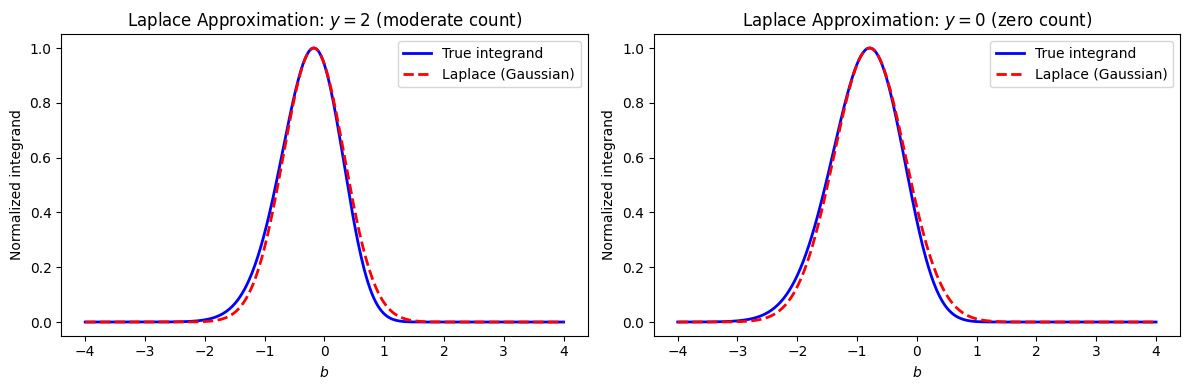

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax_idx, obs_idx in enumerate([0, None]):
    ax = axes[ax_idx]
    if obs_idx is not None:
        yi = y[obs_idx]
        title_suffix = f"$y={yi}$ (moderate count)"
    else:
        # Find a zero count or use 0
        yi = 0
        title_suffix = f"$y={yi}$ (zero count)"

    b_grid = np.linspace(-4, 4, 500)
    log_integrand = (
        yi * (beta0_true + b_grid)
        - np.exp(beta0_true + b_grid)
        - b_grid**2 / (2 * sigma_true**2)
    )
    # Normalize for visualization
    integrand = np.exp(log_integrand - np.max(log_integrand))

    # Find mode and curvature for Laplace
    def neg_h_b(b):
        return -(yi * (beta0_true + b) - np.exp(beta0_true + b)
                 - b**2 / (2 * sigma_true**2))

    res = minimize_scalar(neg_h_b, bounds=(-5, 5), method="bounded")
    b_hat = res.x
    h_double_prime = -(np.exp(beta0_true + b_hat) + 1.0 / sigma_true**2)
    sigma_lap = np.sqrt(-1.0 / h_double_prime)

    laplace_approx = np.exp(-0.5 * ((b_grid - b_hat) / sigma_lap)**2)

    ax.plot(b_grid, integrand, "b-", linewidth=2, label="True integrand")
    ax.plot(b_grid, laplace_approx, "r--", linewidth=2, label="Laplace (Gaussian)")
    ax.set_xlabel("$b$")
    ax.set_ylabel("Normalized integrand")
    ax.set_title(f"Laplace Approximation: {title_suffix}")
    ax.legend()

plt.tight_layout()

For moderate counts, the integrand is nearly Gaussian and the Laplace approximation is excellent. For zero counts, the integrand can be skewed (the Poisson term pulls the mode toward $-\infty$ while the prior pulls it back), and the Gaussian approximation is less accurate.

### Marginal Log-Likelihood Optimization

In practice, we use the Laplace approximation not just for a single integral but to optimize the marginal log-likelihood over the model parameters. For our Poisson-lognormal model, we want to find $(\hat{\beta}_0, \hat{\sigma})$ that maximize $\ell(\beta_0, \sigma) = \sum_{i=1}^n \log L_i(\beta_0, \sigma)$:

In [59]:
def marginal_loglik_laplace(params, y_data):
    """Marginal log-likelihood using Laplace approximation for each observation."""
    beta0, log_sigma = params
    sigma = np.exp(log_sigma)
    total_loglik = 0.0
    for yi in y_data:
        Li = laplace_marginal_lik(yi, beta0, sigma)
        if Li > 0:
            total_loglik += np.log(Li)
        else:
            total_loglik += -1e10  # penalty for numerical failure
    return total_loglik


def marginal_loglik_quad(params, y_data):
    """Marginal log-likelihood using exact quadrature for each observation."""
    beta0, log_sigma = params
    sigma = np.exp(log_sigma)
    total_loglik = 0.0
    for yi in y_data:
        Li, _ = quad(poisson_lognormal_integrand, -np.inf, np.inf,
                     args=(yi, beta0, sigma))
        if Li > 0:
            total_loglik += np.log(Li)
        else:
            total_loglik += -1e10
    return total_loglik


# Optimize using Laplace-based marginal likelihood
from scipy.optimize import minimize

res_laplace = minimize(
    lambda p: -marginal_loglik_laplace(p, y),
    x0=[0.5, np.log(0.5)],
    method="Nelder-Mead",
)
beta0_lap, logsig_lap = res_laplace.x
sigma_lap = np.exp(logsig_lap)

# Optimize using exact quadrature (slow but accurate)
res_quad = minimize(
    lambda p: -marginal_loglik_quad(p, y),
    x0=[0.5, np.log(0.5)],
    method="Nelder-Mead",
)
beta0_quad_opt, logsig_quad = res_quad.x
sigma_quad_opt = np.exp(logsig_quad)

print(f"True parameters:    beta0={beta0_true:.3f}, sigma={sigma_true:.3f}")
print(f"Laplace MLE:        beta0={beta0_lap:.3f}, sigma={sigma_lap:.3f}")
print(f"Quadrature MLE:     beta0={beta0_quad_opt:.3f}, sigma={sigma_quad_opt:.3f}")

True parameters:    beta0=1.000, sigma=0.800
Laplace MLE:        beta0=0.894, sigma=0.629
Quadrature MLE:     beta0=0.893, sigma=0.635


The Laplace-based optimizer runs much faster than exact quadrature (which calls `scipy.integrate.quad` for each of the $n$ observations at every optimization step). For this model, the Laplace estimates are close to the exact quadrature estimates, demonstrating that the approximation error is small relative to the statistical uncertainty.

### Multivariate Extension

The Laplace approximation generalizes naturally to $d$ dimensions. For $I = \int e^{h(\mathbf{x})} d\mathbf{x}$ with mode $\hat{\mathbf{x}}$:

$$I \approx e^{h(\hat{\mathbf{x}})} \cdot (2\pi)^{d/2} \cdot |\mathbf{H}|^{-1/2}$$

where $\mathbf{H} = -\nabla^2 h(\hat{\mathbf{x}})$ is the negative Hessian at the mode. This requires only finding the mode (via Newton-Raphson) and computing the Hessian, both of which scale polynomially in $d$. This makes Laplace approximation one of the few methods that remains computationally feasible in high dimensions.

This is the basis of **PQL (penalized quasi-likelihood)** for GLMMs and **INLA (Integrated Nested Laplace Approximation)** for Bayesian hierarchical models, where Laplace approximations are applied to each conditional posterior in a nested fashion.

### Question

What is the connection between the Laplace approximation and Newton-Raphson optimization? For what class of integrands is the Laplace approximation exact?

### Answer

The Laplace approximation requires finding the mode $\hat{x}$ where $h'(\hat{x}) = 0$ and computing the curvature $h''(\hat{x})$. Newton-Raphson does exactly this: it iterates $x^{(t+1)} = x^{(t)} - h'(x^{(t)})/h''(x^{(t)})$ to find the root of $h'(x)$. The Hessian $h''(\hat{x})$ computed at convergence is precisely what Laplace needs for the variance of the Gaussian approximation. So the Laplace approximation is a direct byproduct of Newton-Raphson optimization.

The Laplace approximation is exact when $h(x)$ is a quadratic function (i.e., the integrand is Gaussian), because the second-order Taylor expansion captures the entire function with no remainder. This happens when both the likelihood and prior are Gaussian, as in the normal-normal conjugate model. For non-Gaussian integrands, the approximation improves as the data become more informative (larger sample size), because the posterior concentrates and becomes more Gaussian by a Bernstein-von Mises-type argument.

### Question

Can the Laplace approximation fail? Give an example of a posterior for which it would give a poor approximation.

### Answer

The Laplace approximation fails for multimodal posteriors. It approximates the integrand by a single Gaussian centered at the mode, so it captures only one peak. If the posterior has two well-separated modes of comparable height, the Laplace approximation at the global mode will miss the entire second mode, potentially underestimating the integral by a factor of 2 or worse.

It also performs poorly for highly skewed posteriors (e.g., when the sample size is very small and the prior is non-informative) or for posteriors with heavy tails (e.g., Cauchy-like posteriors), where the Gaussian approximation to the tails is inadequate. In these cases, the second-order Taylor expansion is a poor representation of the log-integrand away from the mode.

## Method Comparison

Let us now compare all the methods we have developed on the benchmark integral $\int_0^1 e^{-x^2} dx$:

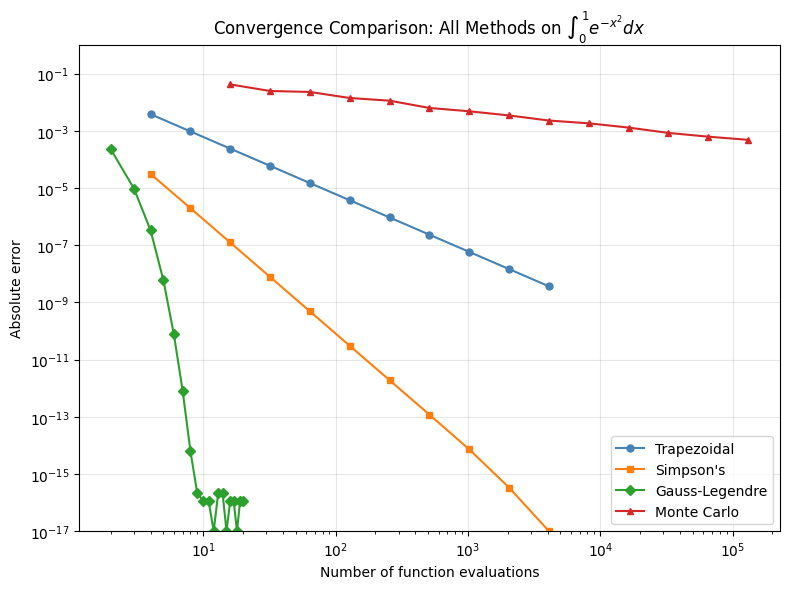

In [52]:
# Grand comparison: all methods on the benchmark integral
methods = {}

# 1. Trapezoidal rule
trap_ns = 2**np.arange(2, 13)
trap_errors = np.array(
    [abs(trapezoidal(f_bench, 0, 1, int(n)) - exact_value) for n in trap_ns]
)
methods["Trapezoidal"] = (trap_ns, trap_errors)

# 2. Simpson's rule
simp_ns = 2**np.arange(2, 13)
simp_errors = np.array(
    [abs(simpsons(f_bench, 0, 1, int(n)) - exact_value) for n in simp_ns]
)
methods["Simpson's"] = (simp_ns, simp_errors)

# 3. Gauss-Legendre
gl_ns = np.arange(2, 21)
gl_errors_comp = []
for n in gl_ns:
    nodes, weights = leggauss(n)
    x = 0.5 * nodes + 0.5
    w = 0.5 * weights
    approx = np.sum(w * f_bench(x))
    gl_errors_comp.append(abs(approx - exact_value))
gl_errors_comp = np.array(gl_errors_comp)
methods["Gauss-Legendre"] = (gl_ns, gl_errors_comp)

# 4. Monte Carlo (multiple runs for smooth curve)
np.random.seed(0)
mc_ns = 2**np.arange(4, 18)
mc_errors_avg = []
n_reps = 50
for n in mc_ns:
    errs = []
    for _ in range(n_reps):
        x_mc_trial = np.random.uniform(0, 1, int(n))
        errs.append(abs(np.mean(np.exp(-x_mc_trial**2)) - exact_value))
    mc_errors_avg.append(np.mean(errs))
mc_errors_avg = np.array(mc_errors_avg)
methods["Monte Carlo"] = (mc_ns, mc_errors_avg)

fig, ax = plt.subplots(figsize=(8, 6))
markers = {"Trapezoidal": "o", "Simpson's": "s", "Gauss-Legendre": "D",
           "Monte Carlo": "^"}
colors = {"Trapezoidal": "steelblue", "Simpson's": "tab:orange",
          "Gauss-Legendre": "tab:green", "Monte Carlo": "tab:red"}

for name, (ns, errs) in methods.items():
    # Replace zeros with small value for log plot
    errs_plot = np.where(errs > 0, errs, 1e-17)
    ax.loglog(ns, errs_plot, f"{markers[name]}-", label=name, color=colors[name],
              markersize=5)

ax.set_xlabel("Number of function evaluations")
ax.set_ylabel("Absolute error")
ax.set_title("Convergence Comparison: All Methods on $\\int_0^1 e^{-x^2} dx$")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(1e-17, 1)
plt.tight_layout()

### Running Example: Method Comparison on Poisson-Lognormal

Let us bring all methods together on the Poisson-lognormal running example. For a single observation, we compare the marginal likelihood estimates from exact quadrature, Gauss-Hermite, Monte Carlo, and Laplace:

In [60]:
# Compare all methods on the Poisson-lognormal for observation y[0]
yi_test = y[0]
print(f"Comparing methods for y[0] = {yi_test}\n")

# Exact quadrature (reference)
Li_ref, _ = quad(poisson_lognormal_integrand, -np.inf, np.inf,
                 args=(yi_test, beta0_true, sigma_true))
print(f"{'Method':<25} {'Estimate':>14} {'Rel Error':>12} {'Eval. Cost':>12}")
print("-" * 65)
print(f"{'Quadrature (reference)':<25} {Li_ref:14.6e} {'---':>12} {'adaptive':>12}")

# Gauss-Hermite with varying nodes
for n_gh in [5, 10, 20]:
    Li_gh_test = marginal_lik_GH(yi_test, beta0_true, sigma_true, n_gh)
    rel = abs(Li_gh_test - Li_ref) / Li_ref
    print(f"{'Gauss-Hermite (n=' + str(n_gh) + ')':<25} {Li_gh_test:14.6e} {rel:12.2e} {n_gh:>12d}")

# Monte Carlo with varying samples
rng_comp = np.random.default_rng(42)
for M_mc in [1000, 10000, 100000]:
    mc_val, _ = marginal_lik_MC(yi_test, beta0_true, sigma_true, M_mc, rng_comp)
    rel = abs(mc_val - Li_ref) / Li_ref
    print(f"{'MC (M=' + str(M_mc) + ')':<25} {mc_val:14.6e} {rel:12.2e} {M_mc:>12d}")

# Laplace
Li_lap_test = laplace_marginal_lik(yi_test, beta0_true, sigma_true)
rel = abs(Li_lap_test - Li_ref) / Li_ref
print(f"{'Laplace':<25} {Li_lap_test:14.6e} {rel:12.2e} {'~10 (NR)':>12}")

Comparing methods for y[0] = 2

Method                          Estimate    Rel Error   Eval. Cost
-----------------------------------------------------------------
Quadrature (reference)      1.655009e-01          ---     adaptive
Gauss-Hermite (n=5)         1.700712e-01     2.76e-02            5
Gauss-Hermite (n=10)        1.654163e-01     5.11e-04           10
Gauss-Hermite (n=20)        1.655015e-01     3.78e-06           20
MC (M=1000)                 1.683561e-01     1.73e-02         1000
MC (M=10000)                1.657481e-01     1.49e-03        10000
MC (M=100000)               1.658291e-01     1.98e-03       100000
Laplace                     1.655544e-01     3.24e-04     ~10 (NR)


For this 1D integral, Gauss-Hermite with 20 nodes achieves near-exact accuracy with minimal computational cost. Laplace provides a fast approximation with small error. Monte Carlo requires many more evaluations to achieve comparable accuracy, confirming that MC is not the method of choice for low-dimensional smooth integrals.

### Summary Table

| Method | Convergence Rate | Dimensionality | Requirements | Best Use Case |
|--------|-----------------|----------------|--------------|---------------|
| Trapezoidal | $O(n^{-2})$ | $O(n^d)$ cost | Smooth integrand | Quick 1D estimates |
| Simpson's | $O(n^{-4})$ | $O(n^d)$ cost | Smooth integrand | Accurate 1D-2D integrals |
| Gauss-Legendre | Exponential | $O(n^d)$ cost | Smooth, known domain | Low-dim smooth integrals |
| Gauss-Hermite | Exponential | $O(n^d)$ cost | Gaussian weight function | GLMMs, normal integrals |
| Monte Carlo | $O(n^{-1/2})$ | Dimension-free | Can sample from domain | High-dimensional integrals |
| Importance Sampling | $O(n^{-1/2})$ | Dimension-free | Good proposal distribution | Rare events, unnormalized targets |
| Laplace | Fixed (asymptotic) | Polynomial in $d$ | Unimodal, smooth integrand | GLMMs (PQL), Bayesian (INLA) |

### Question

For each of the following scenarios, recommend the most appropriate numerical integration method and justify your choice:

(a) Computing the marginal likelihood of a Poisson GLMM with 3 correlated random effects.

(b) Estimating $P(X > 10)$ where $X$ follows a chi-squared distribution with 3 degrees of freedom.

(c) Computing the posterior mean in a hierarchical Bayesian model with 200 random effects.

(d) Evaluating $\int_0^1 \sin(100\pi x) dx$ to high accuracy.

### Answer

(a) **Gauss-Hermite quadrature.** The normal random effects create a Gaussian weight function, and 3 dimensions is low enough that product-rule Gauss-Hermite (say, 15 nodes per dimension = $15^3 = 3375$ evaluations) is very feasible and gives high accuracy. The Poisson likelihood combined with normal random effects has no closed-form marginal, so numerical integration is required.

(b) **Importance sampling.** The probability $P(X > 10)$ for $\chi^2_3$ is a rare event (about $0.019$). Naive MC would need many samples to get precise estimates. IS with a shifted proposal (e.g., a shifted gamma or chi-squared distribution centered near 10) would place most samples in the important region and give accurate estimates with far fewer samples.

(c) **Laplace approximation (INLA) or MCMC.** With 200 random effects, deterministic quadrature is infeasible ($n^{200}$ cost). Laplace approximation is fast and works well if the conditional posteriors are approximately Gaussian. MCMC (specifically Gibbs sampling or HMC) is the gold standard for such hierarchical models but is computationally more expensive.

(d) **Simpson's rule or Gauss-Legendre with many nodes.** This is a 1D integral, so dimension is not an issue. However, $\sin(100\pi x)$ is highly oscillatory, requiring many quadrature nodes to resolve the oscillations (at least 100 nodes for 50 full cycles). Simpson's rule with $n \geq 200$ or Gauss-Legendre with sufficiently many nodes will give high accuracy. Monte Carlo would be very inefficient here because the integrand oscillates rapidly and has high variance under uniform sampling. The exact integral is 0 (by symmetry of the sine function over complete cycles), so MC estimates would fluctuate around 0 with a standard deviation much larger than the true value.

## Summary

We have developed a progression of methods for numerical integration, from simple deterministic rules to sophisticated probabilistic techniques:

1. **Deterministic quadrature** (trapezoidal, Simpson's, Gaussian) provides high accuracy for low-dimensional, smooth integrands. Gaussian quadrature achieves exponential convergence and is the method of choice for GLMM marginal likelihoods when the dimension of random effects is small.

2. **Monte Carlo integration** converts integrals into expectations and uses random sampling. Its $O(n^{-1/2})$ rate is slow for 1D problems but dimension-free, making it essential for high-dimensional integrals.

3. **Importance sampling** redirects sampling effort to important regions, enabling efficient estimation of rare event probabilities and expectations under unnormalized distributions. The proposal must have heavier tails than the target.

4. **Laplace approximation** provides a fast, deterministic alternative by approximating the integrand with a Gaussian at the mode. It connects directly to Newton-Raphson optimization and underlies PQL and INLA for hierarchical models.

These methods connect to what we have already covered and what comes next:

- **EM algorithm:** MCEM used Monte Carlo integration for the E-step. Gauss-Hermite quadrature provides an exact alternative for GLMMs with few random effects. Laplace-based PQL is another approximation strategy for the same integrals.
- **MCMC (next lecture):** When importance sampling struggles (poor proposal) and Laplace is inaccurate (multimodal posterior), Markov chain Monte Carlo generates samples directly from the target distribution, at the cost of correlated samples. The methods in this lecture motivate *why* MCMC is needed.

### References

- Givens, G. H., & Hoeting, J. A. (2013). *Computational Statistics* (2nd ed.). Wiley. Chapters 4-6.
- Robert, C. P., & Casella, G. (2004). *Monte Carlo Statistical Methods* (2nd ed.). Springer. Chapters 3-4.